# Extended Data Fig. 29 — Effect-size distribution of App-specific neuronal decrease

This notebook quantifies the **magnitude** of the App<sup>NL-G-F</sup>-specific NeuN+ decrease across affected brain regions, to show that the detected decreases are real but modest in size.

For each App-specific NeuN-decrease region, the normalized decrease is defined as **1 − (NeuN+ count at 9m / at 1m)**. The distribution is shown as a region-colored stacked histogram (Extended Data Fig. 29a) and as a reverse-cumulative plot (Extended Data Fig. 29b). Across 253 regions the median decrease is 15.4%, and 80% of regions are below 23.1%.

## Input files

Region-level intermediate tables from the whole-brain pipeline (also provided on the project Google Drive):

| File | Content |
|---|---|
| `APP_raw_value_regions_NeuN_decrease.csv` | atlas IDs with App NeuN+ decrease |
| `WT_raw_value_regions_NeuN_decrease.csv` | atlas IDs with WT NeuN+ decrease (subtracted to obtain App-specific set) |
| `APP_raw_value_regions_NeuN_all.csv` | App mean NeuN+ count per region per age |
| `Allen_graph.json` | Allen structure tree (used to assign each region to a major brain division) |

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

In [ ]:
# ---- Input paths (lab data server; tables also on the project Google Drive) ----
region_dir = "/data4/Neurology_project_data_archive/Region/"
allen_graph_path = "/data9/Neurology_project_data_archive/ds1_export3_archive/Imaging/Axial/Neurorology/8w_B6JWT_atlas_1_2022_0924_1847/Allen_graph.json"

# ---- Major brain divisions (Allen structure ids) and display colors ----
labels = ["Isocortex", "OLF", "HPF", "CTXsp", "STR", "PAL", "TH", "HY",
          "MB", "P", "MY", "CB", "fiber tracts", "VS"]
ids    = [315, 698, 1089, 703, 477, 803, 549, 1097, 313, 771, 354, 512, 1009, 73]
colorlist = [(112,255,113),(154,210,189),(126,208,75),(138,218,135),(152,214,249),
             (133,153,204),(255,112,128),(230,68,56),(255,100,255),(255,155,136),
             (255,155,205),(240,240,128),(204,204,204),(170,170,170)]

# Map each atlas region id to its major division via the Allen structure tree
with open(allen_graph_path) as f:
    param_ana = json.load(f)
oya_id = {i: [] for i in ids}
for el in param_ana:
    for ids_i in ids:
        if ids_i in el['structure_id_path']:
            oya_id[ids_i].append(el['id'])
            break

def atlas_to_large_region(atlas_id):
    for rid, lab in zip(ids, labels):
        if atlas_id in oya_id[rid]:
            return lab
    return 'Other'

In [ ]:
# ---- App-specific NeuN-decrease regions and per-region decrease magnitude ----
X      = pd.read_csv(region_dir + 'APP_raw_value_regions_NeuN_decrease.csv', index_col='atlasID')
X_all  = pd.read_csv(region_dir + 'APP_raw_value_regions_NeuN_all.csv', index_col='atlasID')
X2     = pd.read_csv(region_dir + 'WT_raw_value_regions_NeuN_decrease.csv', index_col='atlasID')
X = X[~X.index.isin(X2.index)]                       # App-specific = App-decrease minus WT-decrease

X_specific = X_all.loc[X_all.index.isin(X.index)].copy()
X_specific = X_specific[X_specific['APP_1m'] > 0]
X_specific['decrease_ratio'] = 1 - X_specific['APP_9m'] / X_specific['APP_1m']   # normalized decrease

data_grouped = X_specific[['decrease_ratio']].copy()
data_grouped['large_region'] = data_grouped.index.map(atlas_to_large_region)
print(f'App-specific NeuN-decrease regions: n = {len(data_grouped)}')

## Extended Data Fig. 29a — Region-colored stacked histogram of decrease magnitude

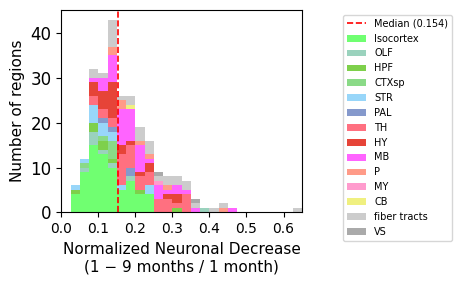

App-specific neuronal decrease regions: n = 253
Mean decrease ratio: 0.173  (= 17.3%)
Median decrease ratio: 0.154  (= 15.4%)
SD: 0.087
Range: 0.031 – 0.638

--- Breakdown by large region ---
CB               1
CTXsp            6
HPF              8
HY              24
Isocortex       71
MB              41
MY               1
OLF              8
Other            1
P                8
PAL              4
STR             14
TH              35
VS               2
fiber tracts    29
Name: large_region, dtype: int64


In [1]:
bins = np.arange(0.0, 0.675, 0.025)
bin_centers = (bins[:-1] + bins[1:]) / 2
data_grouped['bin_idx'] = pd.cut(data_grouped['decrease_ratio'], bins=bins,
                                 labels=range(len(bins)-1), include_lowest=True)
bin_region_counts = (data_grouped.groupby(['bin_idx', 'large_region']).size()
                     .unstack(fill_value=0)
                     .reindex(index=range(len(bins)-1), columns=labels, fill_value=0))

mean_val   = data_grouped['decrease_ratio'].mean()
median_val = data_grouped['decrease_ratio'].median()
std_val    = data_grouped['decrease_ratio'].std()

fig, ax = plt.subplots(figsize=(5, 3))
bottom = np.zeros(len(bin_centers))
for region_label, color in zip(labels, colorlist):
    if region_label in bin_region_counts.columns:
        values = bin_region_counts[region_label].values
        ax.bar(bin_centers, values, bottom=bottom, color=np.array(color)/255.0,
               label=region_label, width=bins[1]-bins[0])
        bottom += values
ax.axvline(median_val, color='red', linestyle='--', linewidth=1.2, label=f'Median ({median_val:.3f})')
ax.set_xlabel('Normalized Neuronal Decrease\n(1 - 9 months / 1 month)', fontsize=11)
ax.set_ylabel('Number of regions', fontsize=11)
ax.set_xticks(np.arange(0, 0.7, 0.1))
ax.set_xticklabels([f'{v:.1f}' for v in np.arange(0, 0.7, 0.1)], fontsize=10)
ax.set_xlim(bins[0], bins[-1]); ax.set_ylim(0, bottom.max()*1.05)
ax.spines['bottom'].set_color('black'); ax.spines['left'].set_color('black')
ax.set_facecolor('none'); ax.grid(False, axis='x')
plt.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig('ED29a_neuronal_decrease_histogram.pdf', transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

print(f'App-specific neuronal decrease regions: n = {len(data_grouped)}')
print(f'Mean decrease ratio: {mean_val:.3f}  (= {mean_val*100:.1f}%)')
print(f'Median decrease ratio: {median_val:.3f}  (= {median_val*100:.1f}%)')
print(f'SD: {std_val:.3f}')
print(f"Range: {data_grouped['decrease_ratio'].min():.3f} - {data_grouped['decrease_ratio'].max():.3f}")
print('\n--- Breakdown by large region ---')
print(data_grouped['large_region'].value_counts().sort_index())

## Extended Data Fig. 29b — Reverse-cumulative distribution (percentile thresholds)

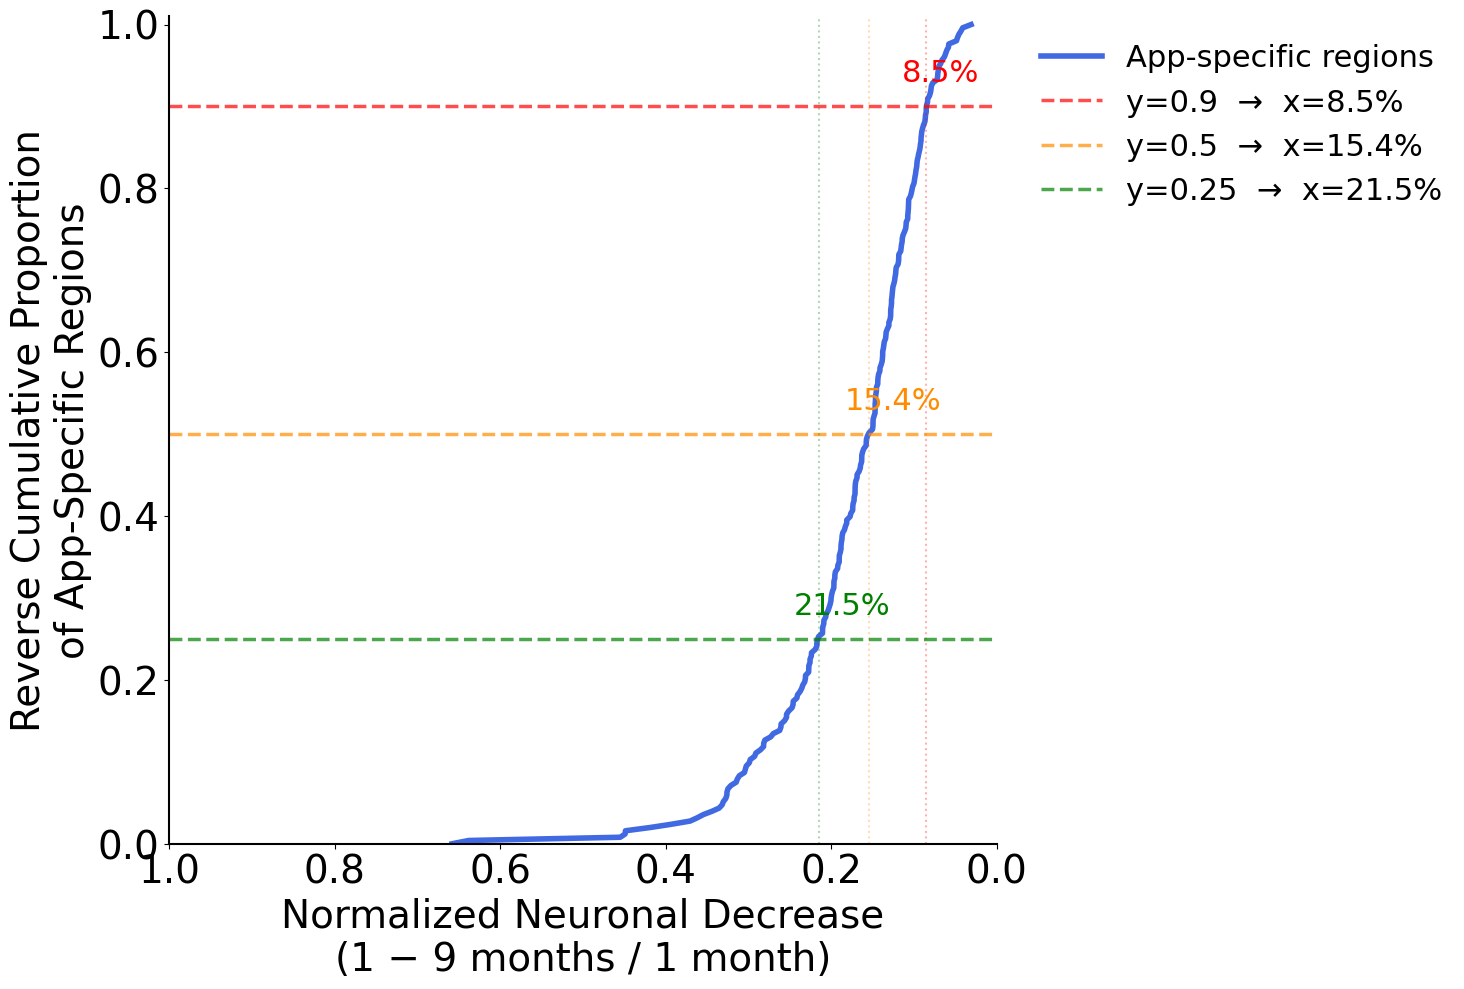

App-specific neuronal decrease regions: n = 253
Mean decrease ratio:   0.173  (= 17.3%)
Median decrease ratio: 0.154  (= 15.4%)

--- Horizontal lines: y-proportion → x-threshold ---
  y = 0.90  →  decrease ≥ 8.5%  [227/253 regions]
  y = 0.50  →  decrease ≥ 15.4%  [127/253 regions]
  y = 0.25  →  decrease ≥ 21.5%  [64/253 regions]

--- Full reverse cumulative table ---
  Y = 0.10 → Decrease ≥ 29.7%  [26/253 regions]
  Y = 0.20 → Decrease ≥ 23.1%  [51/253 regions]
  Y = 0.25 → Decrease ≥ 21.5%  [64/253 regions]
  Y = 0.30 → Decrease ≥ 20.0%  [76/253 regions]
  Y = 0.40 → Decrease ≥ 17.6%  [101/253 regions]
  Y = 0.50 → Decrease ≥ 15.4%  [127/253 regions]
  Y = 0.60 → Decrease ≥ 13.8%  [152/253 regions]
  Y = 0.70 → Decrease ≥ 12.2%  [177/253 regions]
  Y = 0.80 → Decrease ≥ 10.2%  [202/253 regions]
  Y = 0.90 → Decrease ≥ 8.5%  [227/253 regions]


In [2]:
decrease_vals = data_grouped['decrease_ratio'].dropna()
sorted_data = np.sort(decrease_vals.values)[::-1]                 # descending
cumulative_y = np.arange(1, len(sorted_data)+1) / len(sorted_data)
all_sorted_asc = np.sort(decrease_vals.values)
n = len(all_sorted_asc)

hline_props = [0.9, 0.5, 0.25]
hline_colors = ['red', 'darkorange', 'green']
hline_x = {p: np.percentile(all_sorted_asc, (1-p)*100) for p in hline_props}
median_val = np.median(decrease_vals.values); mean_val = np.mean(decrease_vals.values)

fig, ax = plt.subplots(figsize=(14, 10)); ax.set_box_aspect(1)
ax.plot(np.insert(sorted_data, 0, sorted_data[0]+0.02), np.insert(cumulative_y, 0, 0),
        linewidth=4, color='royalblue', label='App-specific regions')
for prop, color in zip(hline_props, hline_colors):
    x_val = hline_x[prop]
    ax.axhline(y=prop, color=color, alpha=0.7, linestyle='--', linewidth=2.5,
               label=f'y={prop}  ->  x={x_val*100:.1f}%')
    ax.axvline(x=x_val, color=color, alpha=0.3, linestyle=':', linewidth=1.5)
    ax.annotate(f'{x_val*100:.1f}%', xy=(x_val, prop), xytext=(x_val+0.03, prop+0.03),
                fontsize=22, color=color, ha='left')
ax.set_xlabel('Normalized Neuronal Decrease\n(1 - 9 months / 1 month)', fontsize=28)
ax.set_ylabel('Reverse Cumulative Proportion\nof App-Specific Regions', fontsize=28)
ax.tick_params(axis='both', which='major', labelsize=28)
ax.set_xlim(1.0, 0); ax.set_ylim(0, 1.01)
ax.set_xticks(np.arange(0, 1.1, 0.2)); ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=22, frameon=False)
plt.tight_layout()
plt.savefig('ED29b_neuronal_decrease_reverse_cumulative.pdf', transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

print(f'App-specific neuronal decrease regions: n = {len(sorted_data)}')
print(f'Mean decrease ratio:   {mean_val:.3f}  (= {mean_val*100:.1f}%)')
print(f'Median decrease ratio: {median_val:.3f}  (= {median_val*100:.1f}%)')
print('\n--- Reverse cumulative: proportion of regions with decrease >= threshold ---')
for prop_target in [0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    threshold = np.percentile(all_sorted_asc, (1-prop_target)*100)
    count = np.sum(all_sorted_asc >= threshold)
    print(f'  Y = {prop_target:.2f} -> Decrease >= {threshold*100:.1f}%  [{count}/{n} regions]')